<a href="https://colab.research.google.com/github/AnshikaG08/DL_CASE_STUDIES/blob/main/Anshika_DL_CS3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [ ]:
img_size = 224
batch_size = 32

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    'dataset/train',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

Found 203 images belonging to 2 classes.


In [ ]:
val_generator = train_datagen.flow_from_directory(
    'dataset/train',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 50 images belonging to 2 classes.


In [ ]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))

model.add(layers.Dense(2, activation='softmax'))

c:\Users\Radhika Sharma\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

c:\Users\Radhika Sharma\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.5561 - loss: 1.2184 - val_accuracy: 0.6400 - val_loss: 0.7046
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7878 - loss: 0.5053 - val_accuracy: 0.7400 - val_loss: 0.5157
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8038 - loss: 0.4529 - val_accuracy: 0.7600 - val_loss: 0.6070
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 934ms/step - accuracy: 0.8435 - loss: 0.3481 - val_accuracy: 0.8000 - val_loss: 0.5633
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 993ms/step - accuracy: 0.8391 - loss: 0.2969 - val_accuracy: 0.8000 - val_loss: 0.4829
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 894ms/step - accuracy: 0.9513 - loss: 0.1784 - val_accuracy: 0.8200 - val_loss: 0.4940
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9653 - loss: 0.1525 - val_accuracy: 0.8200 - val_loss: 0.6020
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9960 - loss: 0.0442 - val_accuracy: 0.8400 - val_loss: 0.5260
Epoch 9

In [ ]:
loss, accuracy = model.evaluate(val_generator)
print('Validation Accuracy:', accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - accuracy: 0.8175 - loss: 0.7710
Validation Accuracy: 0.8199999928474426


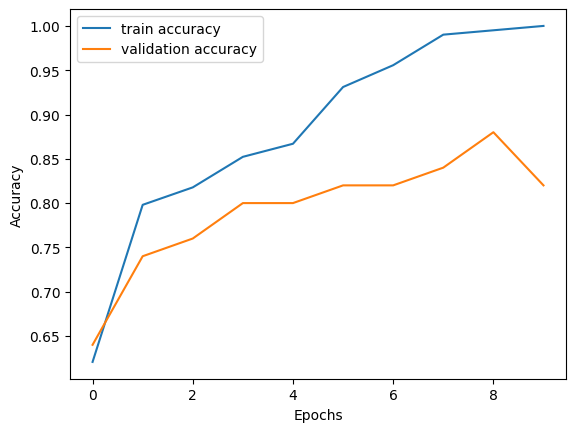

In [ ]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()